# **Práctica 2.2**: Ataques adversarios y robustez en visión artificial con modelos de Deep Learning

TODO: Introducción a la práctica, bla bla bla

---
### **Imports** necesarios y **fijado** **de** **semilla** para garantizar la reproducibilidad del notebook

In [146]:
import torch
import numpy as np
import random
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

if torch.cuda.is_available(): device = "cuda"
elif torch.backends.mps.is_available(): device = "mps"
else: device = "cpu"

print(f"El notebook se ejecutará en el dispositivo: [{device}]!")

El notebook se ejecutará en el dispositivo: [mps]!


### **Definición de funciones necesarias durante el notobook**

In [ ]:
def train_model(model, epochs, optim, criterion, train_dataloader, device):
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for imgs, labels in train_dataloader:
            imgs, labels = imgs.to(device), labels.to(device)

            optim.zero_grad()
            outpus = model(imgs)
            loss = criterion(outpus, labels)
            loss.backward()
            optim.step()

            train_loss += loss.item()
        
        print(f'Epoca {epoch+1} - Loss: {train_loss / len(train_dataloader):.4f}')
    
    return model

def eval_model(model, test_dataloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in tqdm(test_dataloader, desc='Evaluando modelo ...'):
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            predicted = torch.argmax(outputs, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return correct / total

def visualize_predictions(model, loader, classes):
    model.eval()
    images, labels = next(iter(loader)) # Accedemos al primer batch del loader
    images, labels = images.to(device), labels.to(device)
    
    outputs = model(images)
    preds = torch.argmax(outputs, 1)
    plt.figure(figsize=(12, 5))
    for i in range(5): 
        plt.subplot(1, 5, i+1)
        img = images[i].cpu().numpy().transpose((1, 2, 0))
        plt.imshow(img.clip(0, 1))
        color = "green" if preds[i] == labels[i] else "red"
        plt.title(f"P: {classes[preds[i]]}\nReal: {classes[labels[i]]}", color=color)
        plt.axis('off')
    plt.show()

---
## **Parte 1 - Modelo base sobre CIGAR-10**

bla bla bla

En esta misma celda, gracias a que la librería `torchvision` tiene integrado el conjunto de datos `CIFAR-10`, el cual es el solicitado en el enunciado de la práctica, se caraga el conjunto de entrenamiento y test, y se aplica la normalización y transformación a tensor.

In [148]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

/Users/alvaro/Desktop/IA/4º/2ºcuatrimestre/IA en Ciberseguridad/Practicas/Practica2/CNN-Adversarial-Attacks-Defense/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [149]:
class SimpleCNN(nn.Module):
    def __init__(self, mean, std):
        super().__init__()

        self.register_buffer('mean', torch.tensor(mean).view(1, 3, 1, 1)) # se guardan como buffers para evitar errores de mover el modelo de dispositivo [N, C, H, W]
        self.register_buffer('std', torch.tensor(std).view(1, 3, 1, 1))

        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.linear_layer = nn.Sequential(
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(512, 10)
        )
    
    def forward(self, x):
        x = (x - self.mean) / self.std
        x = self.layer1(x)
        x = self.layer2(x)
        x = x.view(-1, 64*8*8)
        x = self.linear_layer(x)
        return x

mean = [0.4914, 0.4822, 0.4465]
std = [0.2023, 0.1994, 0.2010]
model = SimpleCNN(mean, std).to(device)
print('[INFO] Red CNN definida de manera exitosa!')

[INFO] Red CNN definida de manera exitosa!


In [150]:
criterion = nn.CrossEntropyLoss()
optim = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

model = train_model(model, 20, optim, criterion, train_loader, device)

Epoca 1 - Loss: 1.3503
Epoca 2 - Loss: 0.9508
Epoca 3 - Loss: 0.7848
Epoca 4 - Loss: 0.6571
Epoca 5 - Loss: 0.5434
Epoca 6 - Loss: 0.4416
Epoca 7 - Loss: 0.3467
Epoca 8 - Loss: 0.2764
Epoca 9 - Loss: 0.2197
Epoca 10 - Loss: 0.1811
Epoca 11 - Loss: 0.1459
Epoca 12 - Loss: 0.1268
Epoca 13 - Loss: 0.1187
Epoca 14 - Loss: 0.1023
Epoca 15 - Loss: 0.0953
Epoca 16 - Loss: 0.0924
Epoca 17 - Loss: 0.0825
Epoca 18 - Loss: 0.0802
Epoca 19 - Loss: 0.0770
Epoca 20 - Loss: 0.0731


In [151]:
eval_model(model, test_loader)

Evaluando modelo ...: 100%|██████████| 79/79 [00:00<00:00, 158.35it/s]


0.7306

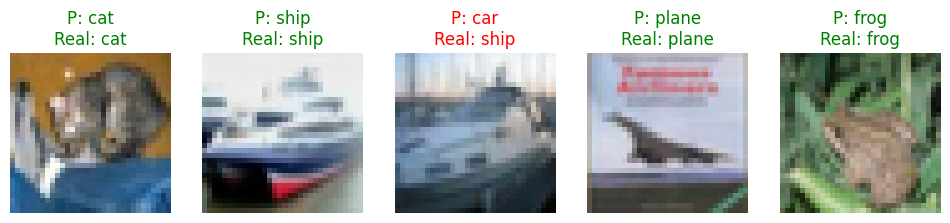

In [152]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
visualize_predictions(model, test_loader, classes)

---
## **Parte 2 - Ataques adversarios**

Durante este apartado del cuaderno, se implementarán dos de los ataques propuesto en el enunciado de la práctica y haremos uso de ellos para "infectar" nuestro modelo entrenado en la anterior parte.

A continuación se implementan una serie funciones necesarias para la evaluación de los diferentes tipos de ataques que se implementarán y probaran durante este notebook.

In [153]:
def compute_norms(delta, l0_thresh=1e-6):
    """
    Calcula las normas L0, L2 y Linf para un batch de perturbaciones en PyTorch.
    delta: torch.Tensor de forma (N, C, H, W)
    """
    # 1. Valor absoluto de la perturbación
    delta_abs = torch.abs(delta)
    
    l_inf = torch.amax(delta_abs, dim=[1, 2, 3])
    l2 = torch.norm(delta.view(delta.shape[0], -1), p=2, dim=1)
    l0 = torch.sum((delta_abs > l0_thresh).float(), dim=[1, 2, 3])
    
    return l0, l2, l_inf


def evaluate_attack(model: SimpleCNN, data_loader: DataLoader, attack_fn: callable, attack_params: dict, device: torch.device):
    
    n_total = 0
    n_clean_correct = 0
    n_adv_correct = 0
    n_succes_attack = 0

    l0_list, l2_list, linf_list = [], [], []

    model.eval()

    for x, y in tqdm(data_loader, desc="Evaluando ataque sobre conjunto de datos"):
        x, y = x.to(device), y.to(device)
        
        with torch.no_grad():
            out = model(x)
            pred_clean = torch.argmax(out, dim=1)


        x_adv = attack_fn(model, x, y, **attack_params)
        with torch.no_grad():
            out = model(x_adv)
            pred_adv = torch.argmax(out, dim=1)

        n_batch = x.shape[0]
        n_total += n_batch

        clear_correct_mask = (y == pred_clean)
        adv_correct_mask = (y == pred_adv)
        adv_wrong_mask = (y != pred_adv)

        n_clean_correct += clear_correct_mask.sum().item()
        n_adv_correct += adv_correct_mask.sum().item()
        n_succes_attack += (clear_correct_mask & adv_wrong_mask).sum().item()

        delta = x_adv - x
        l0, l2, linf = compute_norms(delta)
        l0_list.extend(l0.detach().cpu().numpy())
        l2_list.extend(l2.detach().cpu().numpy())
        linf_list.extend(linf.detach().cpu().numpy())
    
    clean_acc = n_clean_correct / n_total
    adv_acc = n_adv_correct / n_total
    ASR = n_succes_attack / (n_clean_correct + 1e-9)

    res = {
        "clean_accuracy": clean_acc,
        "robust_accuracy": adv_acc,
        "ASR": ASR,
        "mean_L0": float(np.mean(l0_list)),
        "mean_L2": float(np.mean(l2_list)),
        "mean_Linf": float(np.mean(linf_list))
    }

    return res


A continuación, se implementa el ataque `PGD` con `pytorch`:

In [154]:
def _pgd_core(model: SimpleCNN, x: torch.tensor, y: torch.tensor, steps: int, alpha, epsilon: float, clip_min:float = 0.0, clip_max: float = 1.0):
    
    x_adv = x.clone().detach()

    noise = torch.empty_like(x).uniform_(-epsilon, epsilon).to(x.device)
    x_adv = x_adv + noise
    x_adv = torch.clamp(x_adv, clip_min, clip_max)

    x_adv.requires_grad_(True)

    criterion = nn.CrossEntropyLoss()

    for _ in range(steps):

        out = model(x_adv)
        loss = criterion(out, y)
        loss.backward()

        with torch.no_grad():
            grad_sing = torch.sign(x_adv.grad)
            x_adv.data = x_adv.data + alpha * grad_sing
            x_adv.data = x.data + torch.clamp(x_adv.data - x.data, min=-epsilon, max=epsilon)
            x_adv.data = torch.clamp(x_adv.data, clip_min, clip_max)
        
        x_adv.grad.zero_()
          
    return x_adv.detach()


def pgd_attack(model: SimpleCNN, x: torch.tensor, y: torch.tensor, restarts: int, steps: int, alpha: float = None, epsilon: float = 0.1, min_clip: float = 0.0, max_clip: float = 1.0):
    """
    Implementación del ataque PGD con posibilidad de varios reinicios 
    """
    model.eval()
    if alpha is None:
        alpha = epsilon / steps
    
    criterion = nn.CrossEntropyLoss(reduction='none')

    if restarts <= 1:
        return _pgd_core(model, x, y, steps, alpha, epsilon, min_clip, max_clip)
    
    best_x_adv = x.clone().detach()
    best_loss = torch.full((x.shape[0],), -1e9, device=x.device)
    for _ in range(restarts):
        x_adv_candidate = _pgd_core(model, x, y, steps, alpha, epsilon, min_clip, max_clip)
        with torch.no_grad():
            out = model(x_adv_candidate)
            current_loss = criterion(out, y)
        
            better = current_loss > best_loss
            best_loss[better] = current_loss[better]

            best_x_adv[better] = x_adv_candidate[better]

    return best_x_adv

In [163]:
attack_params = {
    'restarts': 5, 
    'steps': 1, 
    'epsilon': 0.01,
}

print(evaluate_attack(model, test_loader, pgd_attack, attack_params, device))

Evaluando ataque sobre conjunto de datos: 100%|██████████| 79/79 [00:04<00:00, 16.62it/s]

{'clean_accuracy': 0.7306, 'robust_accuracy': 0.2702, 'ASR': 0.6301669860387858, 'mean_L0': 3053.275634765625, 'mean_L2': 0.45230624079704285, 'mean_Linf': 0.010000020265579224}


---
## **Parte 3 - Evaluación de robustez**

Para luego la parte de probar el ataque según diferentes parámetros, será interesante sobre todo probar los diferentes valores de $\epsilon$, viendo tanto como afecta al rendimiento del modelo como a como afecta a la perceptibilidad de las imágenes modificadas.

Se ha modificado el flujo de datos para realizar la normalización estadística dentro de la propia arquitectura del modelo. Esto permite que el espacio de búsqueda del ataque adversario coincida con el espacio físico de la imagen $$, garantizando la interpretabilidad de las métricas de perturbación $L$ y evitando artefactos durante el proceso de clipping.

---
## **Parte 4 - Vulnerabilidades y defensas**

## Vulnerabilidades:

En relacion a ataques iterativos sobre norma $L_\infty$ como BIM y el siguietne:

Relación con tu prácticaEn tu análisis de Vulnerabilidades y Defensas (Parte 4), puedes mencionar que:"El éxito del ataque no depende solo del número de pasos, sino de si el presupuesto $\epsilon$ es suficiente para alcanzar la frontera de decisión del modelo antes de que los píxeles se saturen en los límites de la bola $L_\infty$ o en los rangos de color $[1][cite_start]$." Esto demuestra que entiendes por qué, a veces, aumentar los steps de 10 a 100 no mejora el ASR (Attack Success Rate) si el $\epsilon$ es demasiado pequeño.

Comentar tambien que la búsqueda de este valor de $\epsilon$ para nuestro modelo, a veces, también puede llegar a servir para engañar otros modelos (Transferibilidad).